In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score

# %%
# 2. 載入資料
# 請將 raw_data.csv 放在當前工作目錄
df = pd.read_csv('./raw_data/total.csv')

# 檢視前幾筆資料
print(df.head())

   Second_Stroke  age  sex  HLOS  NIHSS  tPA(0/1)  EVT(0/1)  HTN(0/1)  \
0              0   88    0     8      0         0         0         0   
1              0   83    1     7      0         0         0         1   
2              0   72    1     6      0         0         0         1   
3              0   36    0     0      0         1         0         1   
4              0   82    0    11      0         0         0         1   

   DM(0/1)  Dyslipidemia(0/1)  ...  smoking(Y/N/Q)  \
0        0                  0  ...               0   
1        0                  0  ...               0   
2        0                  1  ...               0   
3        0                  1  ...               1   
4        0                  0  ...               0   

   obstructive sleep apnea(0/1)  COVID-19(0/1)   LDL  cholesterol   TG    Cre  \
0                             0              0  57.9          118  117   0.74   
1                             0              0  56.5          106   94   2

In [3]:
print(f"資料維度: {df.shape}")
print(df.info())

資料維度: (1484, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Second_Stroke                 1484 non-null   int64  
 1   age                           1484 non-null   int64  
 2   sex                           1484 non-null   int64  
 3   HLOS                          1484 non-null   int64  
 4   NIHSS                         1484 non-null   int64  
 5   tPA(0/1)                      1484 non-null   int64  
 6   EVT(0/1)                      1484 non-null   int64  
 7   HTN(0/1)                      1484 non-null   int64  
 8   DM(0/1)                       1484 non-null   int64  
 9   Dyslipidemia(0/1)             1484 non-null   int64  
 10  Af(0/1)                       1484 non-null   int64  
 11  smoking(Y/N/Q)                1484 non-null   int64  
 12  obstructive sleep apnea(0/1)  1484 non-null  

In [4]:
# 3.1 缺失值檢查
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


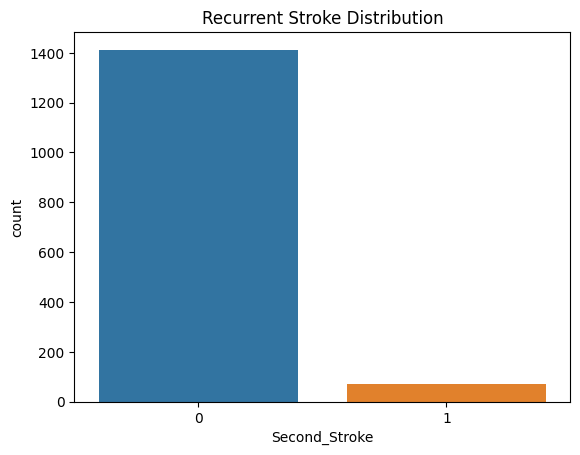

In [5]:
# 3.2 目標變數分布 (假設目標欄位為 'recurrent_stroke')
sns.countplot(data=df, x='Second_Stroke')
plt.title('Recurrent Stroke Distribution')
plt.show()

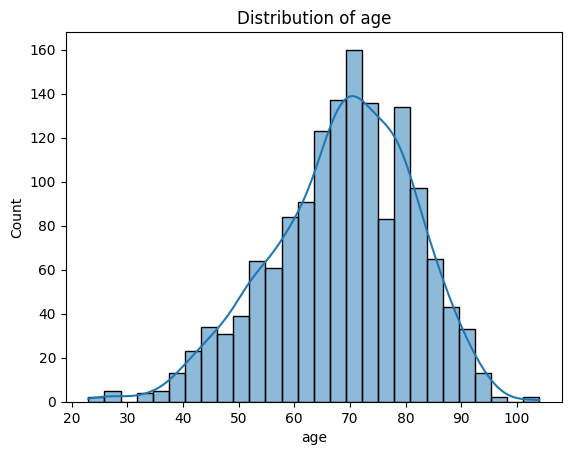

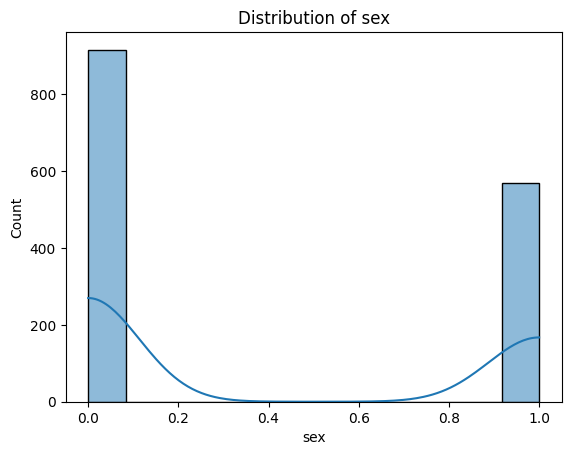

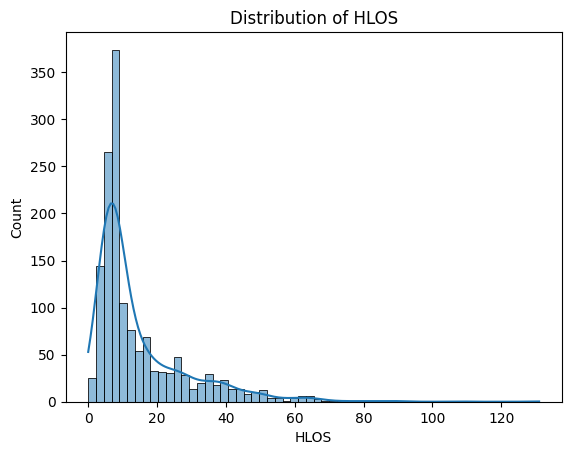

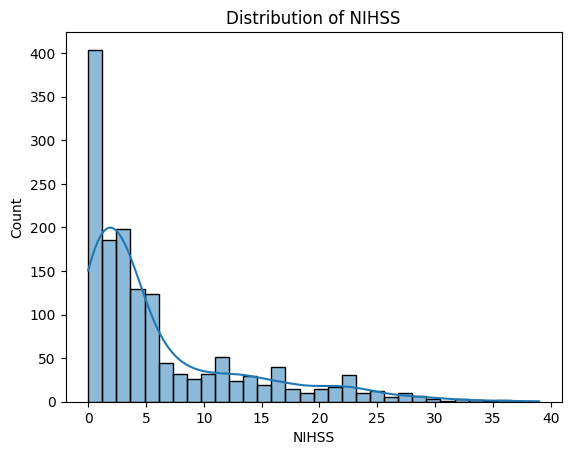

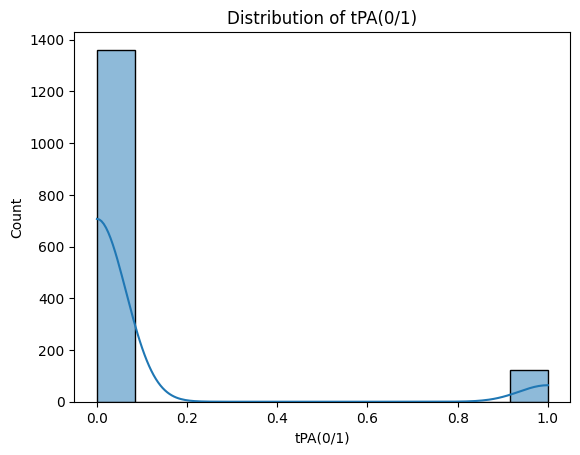

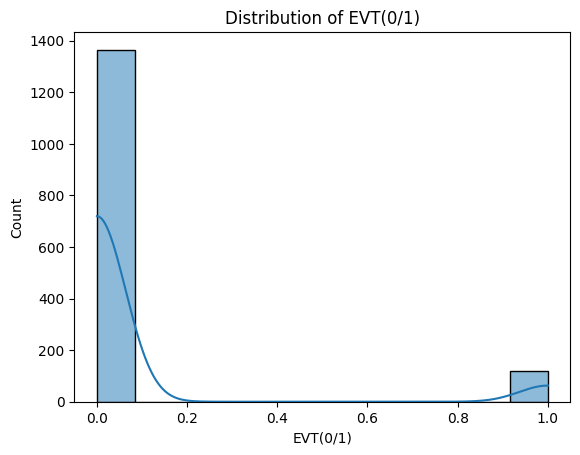

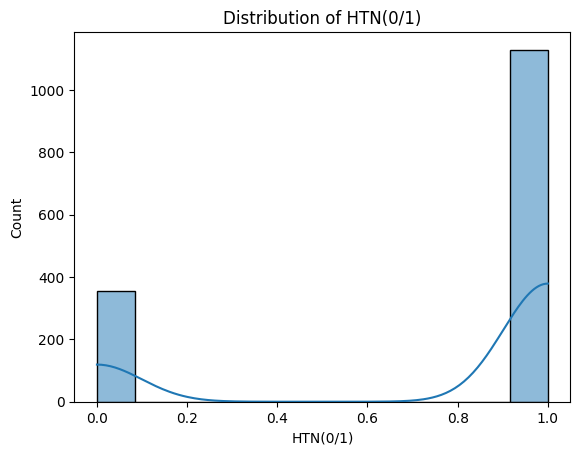

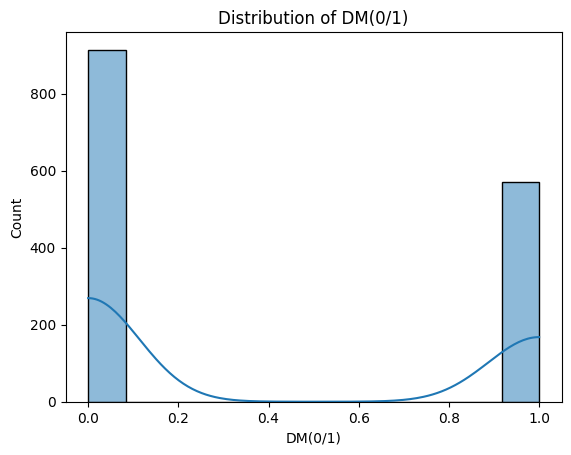

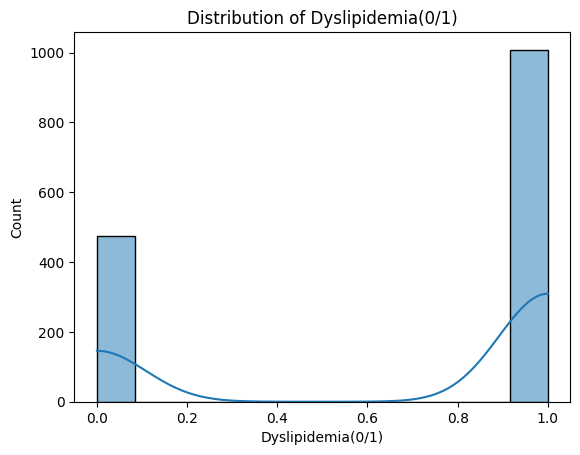

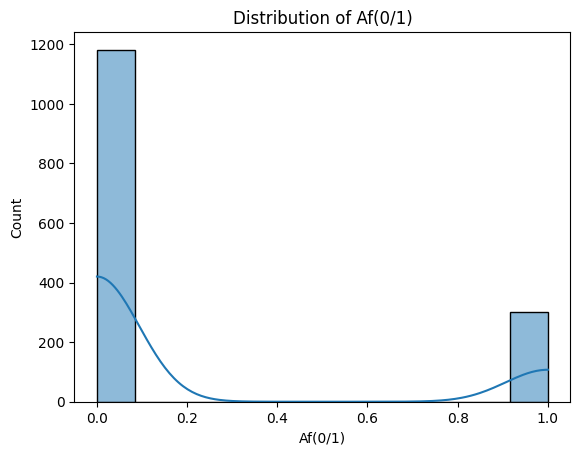

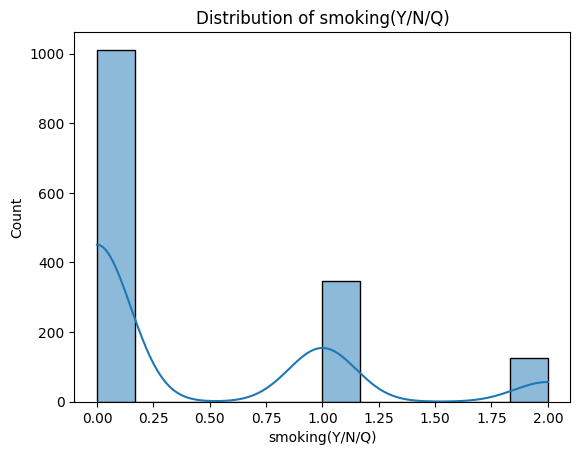

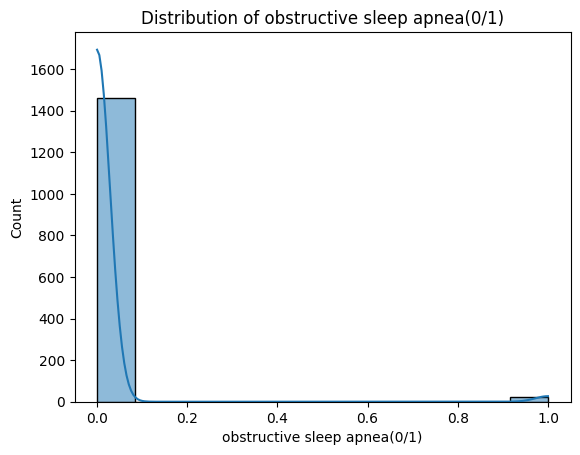

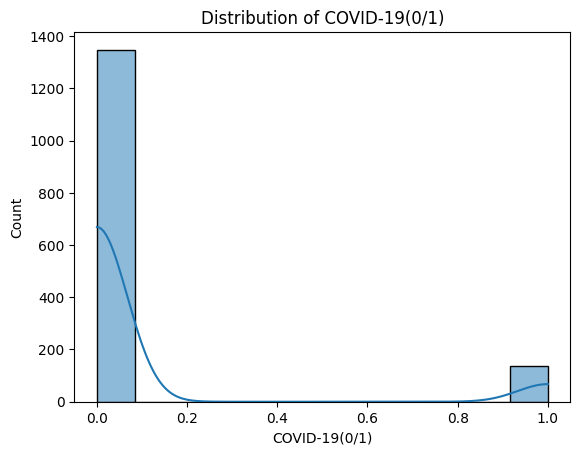

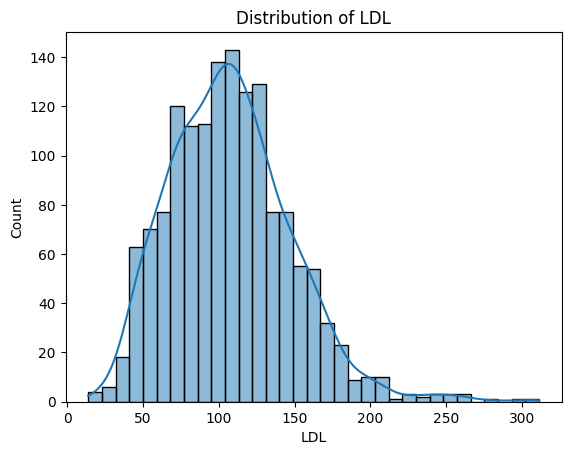

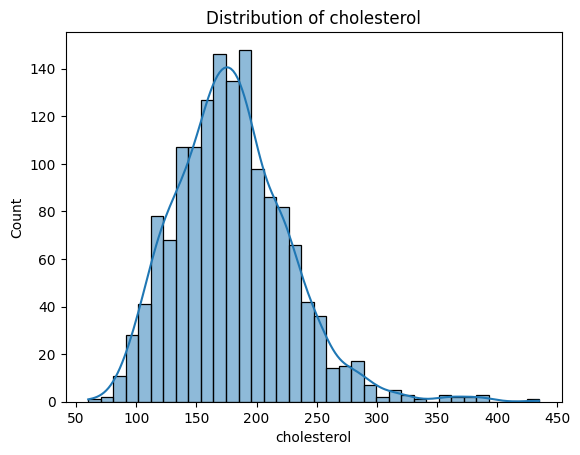

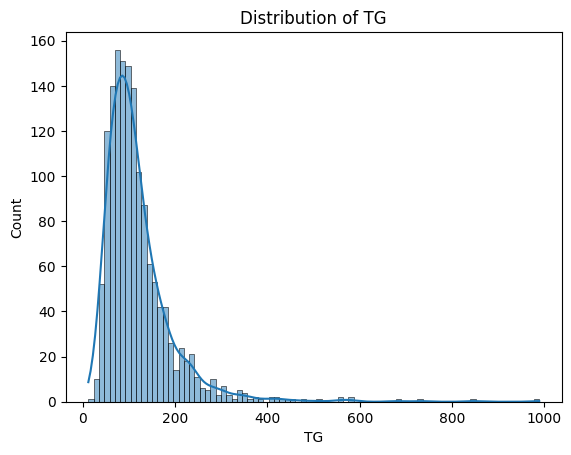

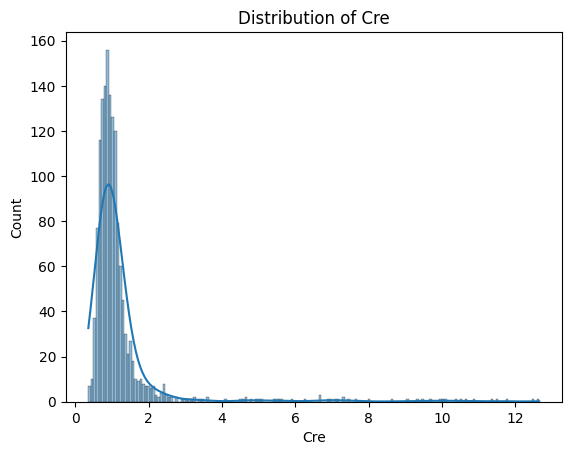

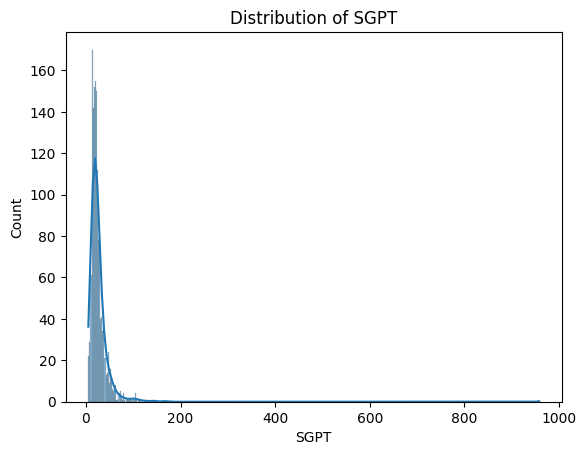

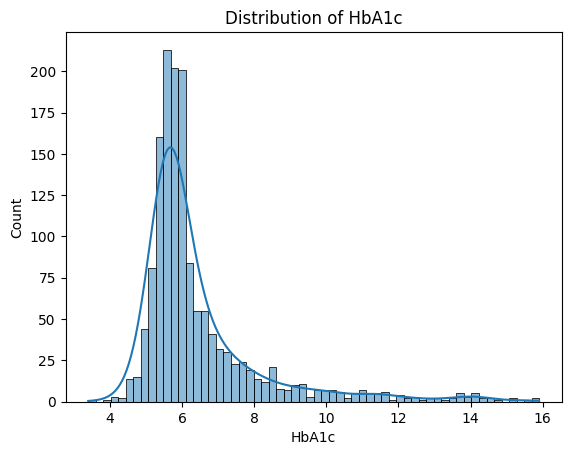

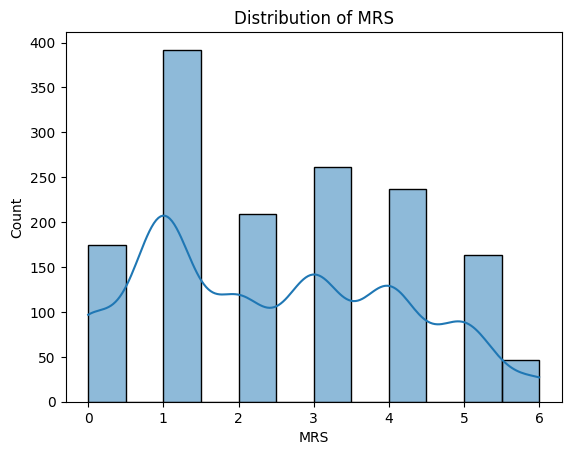

In [6]:
# 3.3 數值特徵分布
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Second_Stroke')
for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

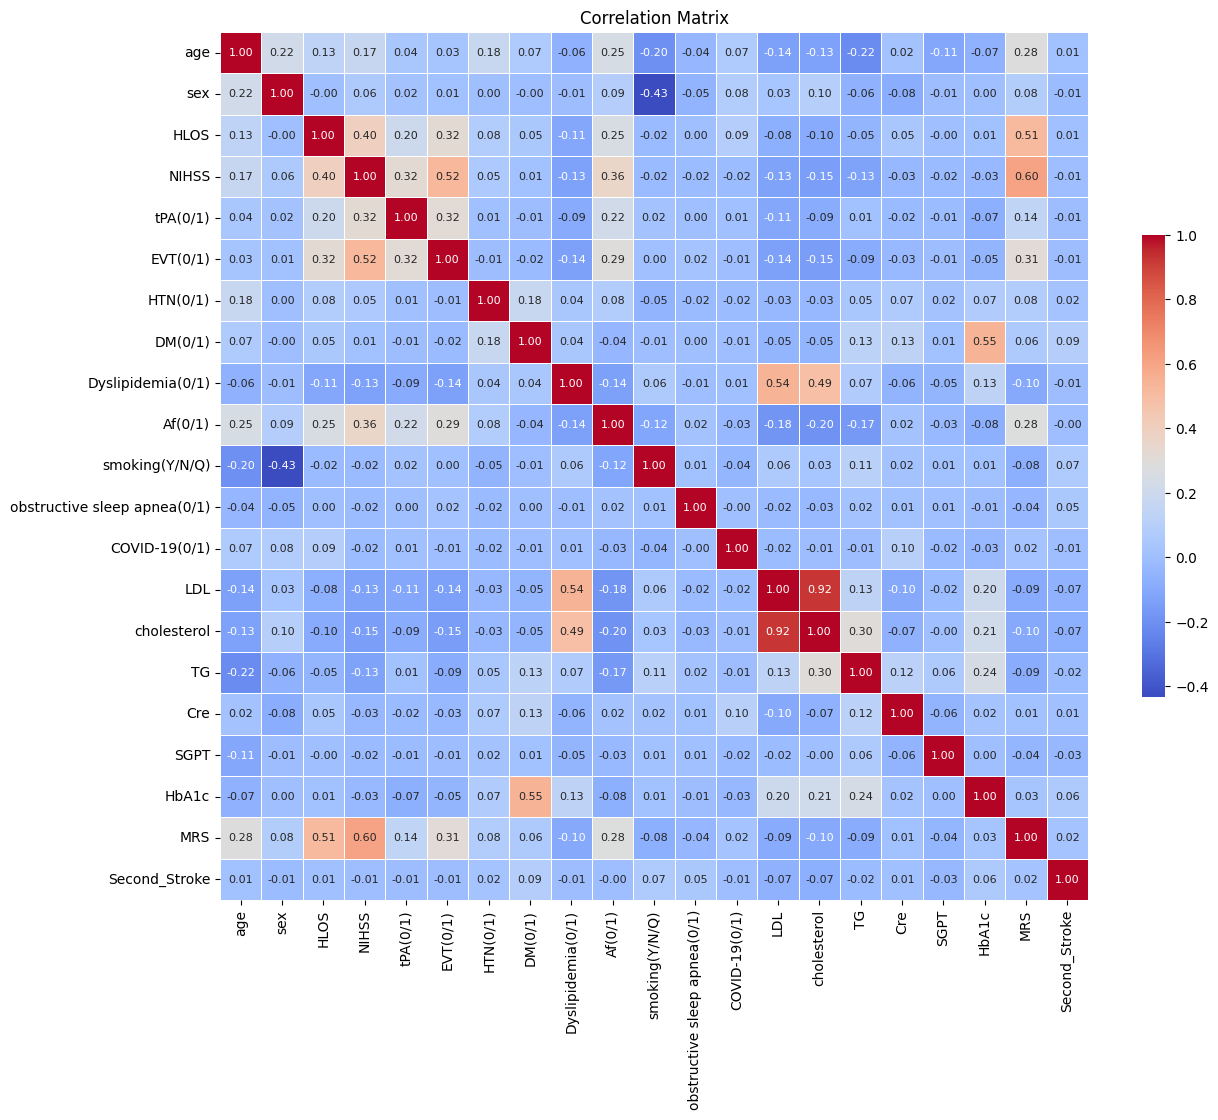

In [7]:
# 3.4 數值特徵相關性熱圖
corr = df[num_cols.tolist() + ['Second_Stroke']].corr()
# 1. 增大画布，2. 缩小整体字体
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',square=True,                 # 更好地保持单元格为正方形
    linewidths=0.5,              # 单元格边框
    cbar_kws={'shrink': 0.5},    # 颜色条缩小
    annot_kws={'size': 8}  )
plt.title('Correlation Matrix')
plt.show()

# Smote

#### 3. 區分連續與離散欄位

In [8]:
target_col = 'Second_Stroke'  # 改成你的目標欄

# 分開 X / y
X = df.drop(columns=[target_col])
y = df[target_col]

bin_cols = ['sex','tPA(0/1)','EVT(0/1)','HTN(0/1)','DM(0/1)',
            'Dyslipidemia(0/1)','Af(0/1)','obstructive sleep apnea(0/1)','COVID-19(0/1)']

cat_cols = ['smoking(Y/N/Q)']
ord_cols = ['MRS']
num_cont_cols = ['age','LDL','cholesterol','TG','Cre','SGPT','HbA1c']
num_count_cols = ['HLOS','NIHSS']   # NIHSS 也可改放 ord_cols

# 從 X（已排除 y）取得特徵全集
feature_cols = list(X.columns)

# ===== 3) 只保留存在於 X 的欄位 =====
def keep_existing(cols): return [c for c in cols if c in feature_cols]
bin_cols       = keep_existing(bin_cols)
cat_cols       = keep_existing(cat_cols)
ord_cols       = keep_existing(ord_cols)
num_cont_cols  = keep_existing(num_cont_cols)
num_count_cols = keep_existing(num_count_cols)

print(f"目標欄位: {target_col}")
print(f"所有特徵（不含目標）({len(feature_cols)}): {feature_cols}")
print(f"二元特徵 bin_cols ({len(bin_cols)}): {bin_cols}")
print(f"名目特徵 cat_cols ({len(cat_cols)}): {cat_cols}")
print(f"有序特徵 ord_cols ({len(ord_cols)}): {ord_cols}")
print(f"連續數值 num_cont_cols ({len(num_cont_cols)}): {num_cont_cols}")
print(f"計數/分數 num_count_cols ({len(num_count_cols)}): {num_count_cols}")

目標欄位: Second_Stroke
所有特徵（不含目標）(20): ['age', 'sex', 'HLOS', 'NIHSS', 'tPA(0/1)', 'EVT(0/1)', 'HTN(0/1)', 'DM(0/1)', 'Dyslipidemia(0/1)', 'Af(0/1)', 'smoking(Y/N/Q)', 'obstructive sleep apnea(0/1)', 'COVID-19(0/1)', 'LDL', 'cholesterol', 'TG', 'Cre', 'SGPT', 'HbA1c', 'MRS']
二元特徵 bin_cols (9): ['sex', 'tPA(0/1)', 'EVT(0/1)', 'HTN(0/1)', 'DM(0/1)', 'Dyslipidemia(0/1)', 'Af(0/1)', 'obstructive sleep apnea(0/1)', 'COVID-19(0/1)']
名目特徵 cat_cols (1): ['smoking(Y/N/Q)']
有序特徵 ord_cols (1): ['MRS']
連續數值 num_cont_cols (7): ['age', 'LDL', 'cholesterol', 'TG', 'Cre', 'SGPT', 'HbA1c']
計數/分數 num_count_cols (2): ['HLOS', 'NIHSS']


### 3. 建前處理器

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline

num_cont_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

# 若覺得 HLOS/NIHSS 右偏，可把 log1p 打開
# APPLY_LOG1P_FOR_COUNT = True
APPLY_LOG1P_FOR_COUNT = False
num_count_steps = [('impute', SimpleImputer(strategy='median'))]
if APPLY_LOG1P_FOR_COUNT:
    num_count_steps.append(('log1p', FunctionTransformer(np.log1p)))
num_count_steps.append(('scale', StandardScaler()))
num_count_pipe = Pipeline(num_count_steps)

bin_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),   # 保留 0/1
])

ord_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

# OneHotEncoder 新舊版本參數相容
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)  # sklearn >=1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)         # 舊版

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe',    ohe),
])

In [10]:
# === 組裝 ColumnTransformer（處理器）===
preprocessor = ColumnTransformer([
    ('num_cont',  num_cont_pipe,  num_cont_cols),
    ('num_count', num_count_pipe,  num_count_cols),
    ('bin',       bin_pipe,        bin_cols),
    ('ord',       ord_pipe,        ord_cols),
    ('cat',       cat_pipe,        cat_cols),
], remainder='drop')

# --- 使用方式 ---
# 1) 只做轉換
Xt = preprocessor.fit_transform(X)
print("轉換後形狀:", Xt.shape)


轉換後形狀: (1484, 22)


# Set exp para

In [11]:
import numpy as np
import pandas as pd

# 參數
TARGET = 'Second_Stroke'   # y 欄
N_VAL_POS = 14             # 驗證集正例數
N_VAL_NEG = 13             # 驗證集負例數
N_NEG_GROUPS = 10          # 負例分成幾組
NEG_PER_GROUP = 140        # 每組負例數（1400/10）
POS_TARGET_AFTER_SMOTE = 140
SEED = 42

In [12]:
# --- 基本檢查 ---
y = df[TARGET].astype(int)
pos_idx = y.index[y == 1].to_numpy()
neg_idx = y.index[y == 0].to_numpy()

assert len(pos_idx) >= N_VAL_POS, "正例不足以抽 validation"
assert len(neg_idx) >= N_VAL_NEG + N_NEG_GROUPS * NEG_PER_GROUP, "負例不足以分組"

rng = np.random.default_rng(SEED)

In [13]:
# 1) 驗證集：從正例取 14、人；負例取 13 人
val_pos = rng.choice(pos_idx, size=N_VAL_POS, replace=False)
pos_train_pool = np.setdiff1d(pos_idx, val_pos, assume_unique=False)  # 剩 57

val_neg = rng.choice(neg_idx, size=N_VAL_NEG, replace=False)
neg_train_pool = np.setdiff1d(neg_idx, val_neg, assume_unique=False)  # 剩 1400

val_idx = np.concatenate([val_pos, val_neg])

In [14]:
# 2) 將 1400 個負例打亂後切成 10 組、每組 140 人
neg_train_shuffled = rng.permutation(neg_train_pool)
neg_groups = np.array_split(neg_train_shuffled, N_NEG_GROUPS)
for g in neg_groups:
    assert len(g) == NEG_PER_GROUP

In [15]:
# 3) 建立 10 個訓練折：每折 = 固定的 57 正例 + 當折的 140 負例
folds = []
for i in range(N_NEG_GROUPS):
    fold = {
        "fold": i,
        "train_pos_idx": pos_train_pool,    # 固定 57 筆（之後用 SMOTE 補到 140）
        "train_neg_idx": neg_groups[i],     # 該折 140 筆
        "val_idx": val_idx,                 # 同一組 27 筆
    }
    folds.append(fold)

In [16]:
# 4) 簡要報告
print(f"總樣本: {len(df)} | 正例: {len(pos_idx)} | 負例: {len(neg_idx)}")
print(f"Validation: {len(val_idx)} (pos={len(val_pos)}, neg={len(val_neg)})")
for f in folds[:3]:  # 只看前三折示意
    print(f"Fold {f['fold']}: train_pos={len(f['train_pos_idx'])} (→SMOTE到 {POS_TARGET_AFTER_SMOTE}), "
          f"train_neg={len(f['train_neg_idx'])}, val={len(f['val_idx'])}")

總樣本: 1484 | 正例: 71 | 負例: 1413
Validation: 27 (pos=14, neg=13)
Fold 0: train_pos=57 (→SMOTE到 140), train_neg=140, val=27
Fold 1: train_pos=57 (→SMOTE到 140), train_neg=140, val=27
Fold 2: train_pos=57 (→SMOTE到 140), train_neg=140, val=27


In [17]:
# 5) 取出某一折的資料（示例：第 k 折）
def get_fold_data(k: int):
    f = folds[k]
    tr_idx = np.concatenate([f["train_pos_idx"], f["train_neg_idx"]])
    X_tr, y_tr = df.loc[tr_idx].drop(columns=[TARGET]), df.loc[tr_idx, TARGET]
    X_val, y_val = df.loc[f["val_idx"]].drop(columns=[TARGET]), df.loc[f["val_idx"], TARGET]
    return X_tr, y_tr, X_val, y_val

In [18]:
# ================== 4) 建立模型 + SVMSMOTE（smote_svm） ==================
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_recall_fscore_support
from imblearn.over_sampling import SVMSMOTE

models = {}
models['SVM-RBF'] = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=SEED)
models['RF']      = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=SEED)
models['AdaBoost']= AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=SEED)
models['GBC']     = GradientBoostingClassifier(random_state=SEED)

# 可選：XGBoost / CatBoost（若未安裝會略過）
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', tree_method='hist', random_state=SEED, n_jobs=-1
    )
except Exception as e:
    print("⚠️ XGBoost 未安裝或不可用，略過。", e)

try:
    from catboost import CatBoostClassifier
    models['CatBoost'] = CatBoostClassifier(
        iterations=500, depth=4, learning_rate=0.05,
        l2_leaf_reg=3, loss_function='Logloss',
        random_seed=SEED, verbose=False
    )
except Exception as e:
    print("⚠️ CatBoost 未安裝或不可用，略過。", e)

def make_pipeline(base_estimator):
    sampler = SVMSMOTE(
        sampling_strategy={1: POS_AFTER_SMOTE},  # 少數類(1)補到 140
        random_state=SEED
    )
    return Pipeline(steps=[
        ('preprocess', preprocessor),
        ('smote_svm', sampler),
        ('model', base_estimator),
    ])

In [19]:
# ================== 0) 清欄名、切 X/y ==================
import numpy as np, pandas as pd
df = df.rename(columns=lambda c: c.strip()).rename(columns={'Hba1C':'HbA1c'})
TARGET = 'Second_Stroke'
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# ================== 1) 欄位分組 ==================
bin_cols = ['sex','tPA(0/1)','EVT(0/1)','HTN(0/1)','DM(0/1)',
            'Dyslipidemia(0/1)','Af(0/1)','obstructive sleep apnea(0/1)','COVID-19(0/1)']
cat_cols = ['smoking(Y/N/Q)']     # 0/1/2 三類（名目）
ord_cols = ['MRS']
num_cont_cols  = ['age','LDL','cholesterol','TG','Cre','SGPT','HbA1c']
num_count_cols = ['HLOS','NIHSS']

feature_cols = list(X.columns)
keep = lambda cols: [c for c in cols if c in feature_cols]
bin_cols, cat_cols, ord_cols = keep(bin_cols), keep(cat_cols), keep(ord_cols)
num_cont_cols, num_count_cols = keep(num_cont_cols), keep(num_count_cols)

# ================== 2) 兩段式前處理 + SMOTENC ==================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

# Part-1: 先把連續特徵處理好、類別做 Ordinal（供 SMOTENC 用）
prep1 = ColumnTransformer([
    ('num_cont',  Pipeline([('imp', SimpleImputer(strategy='median')),
                            ('sc',  StandardScaler())]),               num_cont_cols),
    ('num_count', Pipeline([('imp', SimpleImputer(strategy='median')),
                            ('log', FunctionTransformer(np.log1p)),
                            ('sc',  StandardScaler())]),               num_count_cols),
    ('bin',       SimpleImputer(strategy='most_frequent'),             bin_cols),     # 保留 0/1 值
    ('ord',       SimpleImputer(strategy='median'),                    ord_cols),     # 先不縮放，當作類別
    ('cat_ord',   Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                   unknown_value=-1))]),             cat_cols),
], remainder='drop')

# 計算 prep1 輸出中的各區段索引
def idx_range(start, length): return list(range(start, start+length))
n_cont, n_count, n_bin, n_ord, n_cat = map(len, [num_cont_cols, num_count_cols, bin_cols, ord_cols, cat_cols])

s0 = 0
s1 = s0 + n_cont
s2 = s1 + n_count
s3 = s2 + n_bin
s4 = s3 + n_ord
# s5 = s4 + n_cat  # 末端

idx_cont  = idx_range(s0, n_cont)
idx_count = idx_range(s1, n_count)
idx_bin   = idx_range(s2, n_bin)
idx_ord   = idx_range(s3, n_ord)
idx_cat   = idx_range(s4, n_cat)

categorical_features = idx_bin + idx_ord + idx_cat   # 告訴 SMOTENC 哪些是類別

sampler = SMOTENC(categorical_features=categorical_features,
                  sampling_strategy={1: 140}, random_state=42, n_jobs=-1)

# Part-2: SMOTE 後再做 One-Hot / 縮放（以 ndarray 索引切片）
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

prep2 = ColumnTransformer([
    ('cont',   'passthrough', idx_cont),       # 已縮放
    ('count',  'passthrough', idx_count),      # 已log1p+縮放
    ('bin',    'passthrough', idx_bin),        # 0/1
    ('ord',    StandardScaler(), idx_ord),     # 這時才縮放有序分數
    ('cat',    ohe,            idx_cat),       # 將 Ordinal 的名目再一熱
], remainder='drop')

def make_pipeline(base_estimator):
    return Pipeline(steps=[
        ('prep1', prep1),
        ('smote', sampler),   # ← SMOTENC
        ('prep2', prep2),
        ('model', base_estimator),
    ])

# ================== 3) 10 組資料（固定 validation） ==================
N_VAL_POS, N_VAL_NEG = 14, 13
N_NEG_GROUPS, NEG_PER_GROUP = 10, 140
SEED = 42
rng = np.random.default_rng(SEED)

pos_idx = y.index[y==1].to_numpy()
neg_idx = y.index[y==0].to_numpy()
assert len(pos_idx) >= N_VAL_POS and len(neg_idx) >= N_VAL_NEG + N_NEG_GROUPS*NEG_PER_GROUP

val_pos = rng.choice(pos_idx, size=N_VAL_POS, replace=False)
pos_train_pool = np.setdiff1d(pos_idx, val_pos)
val_neg = rng.choice(neg_idx, size=N_VAL_NEG, replace=False)
neg_train_pool = np.setdiff1d(neg_idx, val_neg)
val_idx = np.concatenate([val_pos, val_neg])
neg_groups = np.array_split(rng.permutation(neg_train_pool), N_NEG_GROUPS)

def get_fold_data(k: int):
    tr_idx = np.concatenate([pos_train_pool, neg_groups[k]])
    return (df.loc[tr_idx].drop(columns=[TARGET]),
            df.loc[tr_idx, TARGET].astype(int),
            df.loc[val_idx].drop(columns=[TARGET]),
            df.loc[val_idx, TARGET].astype(int))

# ================== 4) 模型們（含 XBC 與多種常見模型） ==================
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier

def build_models(SEED=42):
    models = {
        'SVM-RBF':  SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=SEED),
        'RF':       RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=SEED),
        'AdaBoost': AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=SEED),
        'GBC':      GradientBoostingClassifier(random_state=SEED),

        'LR':       LogisticRegression(max_iter=2000, n_jobs=-1, random_state=SEED),
        'ET':       ExtraTreesClassifier(n_estimators=600, n_jobs=-1, random_state=SEED),
        'HGB':      HistGradientBoostingClassifier(random_state=SEED),
        'KNN':      KNeighborsClassifier(n_neighbors=15, weights='distance'),
        'LinearSVC': CalibratedClassifierCV(
            base_estimator=LinearSVC(C=1.0, random_state=SEED),
            method='sigmoid', cv=3
        ),
        'GNB':      GaussianNB(),
        # 決策樹（與 SMOTENC 一起用，class_weight=None 即可）
        'DT': DecisionTreeClassifier(
            max_depth=None, min_samples_leaf=8, random_state=SEED
        ),
        # 比較一個淺樹版本（更穩、較不易過擬合）
        'DT_depth4': DecisionTreeClassifier(
            max_depth=4, min_samples_leaf=10, random_state=SEED
        ),
    }

    try:
        from xgboost import XGBClassifier
        models['XGBoost'] = XGBClassifier(
            n_estimators=600, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', tree_method='hist', random_state=SEED, n_jobs=-1
        )
        models['XBC'] = models['XGBoost']  # 你的 XBC 別名
    except Exception as e:
        print("ℹ️ XGBoost 不可用，略過。", e)

    try:
        from lightgbm import LGBMClassifier
        models['LGBM'] = LGBMClassifier(
            n_estimators=1200, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            objective='binary', random_state=SEED, n_jobs=-1
        )
    except Exception as e:
        print("ℹ️ LightGBM 不可用，略過。", e)

    try:
        from catboost import CatBoostClassifier
        models['CatBoost'] = CatBoostClassifier(
            iterations=800, depth=5, learning_rate=0.05,
            l2_leaf_reg=3, loss_function='Logloss',
            random_seed=SEED, verbose=False
        )
    except Exception as e:
        print("ℹ️ CatBoost 不可用，略過。", e)

    return models

models = build_models(SEED)

ℹ️ LightGBM 不可用，略過。 libgomp.so.1: cannot open shared object file: No such file or directory


In [20]:
# ================== 5) 用 validation 找最佳閾值（以 F1 最大化）並評估 ==================
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_recall_fscore_support, f1_score

def find_best_threshold(y_true, prob, grid=np.linspace(0.05, 0.95, 181)):
    f1s = [f1_score(y_true, (prob >= t).astype(int), zero_division=0) for t in grid]
    i = int(np.argmax(f1s))
    return float(grid[i]), float(f1s[i])

def eval_from_score(y_true, score, name, store_thr=True):
    """給一個連續分數(score)，找 F1 最佳閾值並回傳 metrics 與閾值。"""
    t, _ = find_best_threshold(y_true, score)
    pred = (score >= t).astype(int)
    auc  = roc_auc_score(y_true, score)
    ap   = average_precision_score(y_true, score)
    acc  = accuracy_score(y_true, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, average='binary', zero_division=0)
    row = {'model': name, 'thr': t, 'AUC': auc, 'AP': ap, 'ACC': acc, 'PREC': prec, 'REC': rec, 'F1': f1, 'F1*': f1}
    return row

records = []
for k in range(N_NEG_GROUPS):
    X_tr, y_tr, X_val, y_val = get_fold_data(k)

    # 先跑所有基模型，保存 proba / thr / AP
    fold_proba = {}     # {model_name: proba vector}
    fold_thr   = {}     # {model_name: best threshold on this fold}
    fold_ap    = {}     # {model_name: AP on this fold}

    for name, est in models.items():
        pipe = make_pipeline(est)
        pipe.fit(X_tr, y_tr)

        proba = pipe.predict_proba(X_val)[:, 1]
        t, best_f1 = find_best_threshold(y_val, proba)
        pred = (proba >= t).astype(int)

        auc  = roc_auc_score(y_val, proba)
        ap   = average_precision_score(y_val, proba)
        acc  = accuracy_score(y_val, pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_val, pred, average='binary', zero_division=0)

        # 存下來，等一下投票用
        fold_proba[name] = proba
        fold_thr[name]   = t
        fold_ap[name]    = ap

        records.append({'fold': k, 'model': name, 'thr': t,
                        'AUC': auc, 'AP': ap, 'ACC': acc,
                        'PREC': prec, 'REC': rec, 'F1': f1, 'F1*': best_f1})

    # ===== 這一折做三種投票 =====
    base_models = list(fold_proba.keys())
    if len(base_models) >= 2:
        import numpy as np

        # Soft Voting: 平均
        mat = np.column_stack([fold_proba[m] for m in base_models])
        score_soft_mean = mat.mean(axis=1)
        row = eval_from_score(y_val, score_soft_mean, name='ENS_soft(mean)')
        row['fold'] = k
        records.append(row)

        # Soft Voting: 以 AP 加權的平均
        w = np.array([max(fold_ap[m], 1e-12) for m in base_models], dtype=float)
        w = w / w.sum()
        score_soft_wap = (mat * w).sum(axis=1)
        row = eval_from_score(y_val, score_soft_wap, name='ENS_soft(wAP)')
        row['fold'] = k
        records.append(row)

        # Hard Voting: 先各自用最佳閾值二值化，再多數決；投票比例當作分數
        bin_preds = np.column_stack([(fold_proba[m] >= fold_thr[m]).astype(int) for m in base_models])
        vote_frac = bin_preds.mean(axis=1)  # 0~1 之間的投票比例
        row = eval_from_score(y_val, vote_frac, name='ENS_hard(maj)')
        row['fold'] = k
        records.append(row)
    else:
        print(f"[fold {k:02d}] 可用模型少於 2 個，跳過投票。")

# 彙總
res = pd.DataFrame(records)
summary = (res.groupby('model')
             .agg({'AUC':['mean','std'],'AP':['mean','std'],'ACC':['mean','std'],
                   'PREC':['mean','std'],'REC':['mean','std'],'F1':['mean','std'],
                   'thr':['mean','std']})
             .round(4))
print(summary)

# 想看每折的投票最佳閾值：
# res[res['model'].str.startswith('ENS_')].pivot_table(index='fold', columns='model', values='thr')


/usr/local/lib/python3.8/site-packages/imblearn/over_sampling/_smote/base.py:619: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/imblearn/over_sampling/_smote/base.py:345: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/imblearn/over_sampling/_smote/base.py:619: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/imblearn/over_sampling/_smote/base.py:345: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed i

                   AUC              AP             ACC            PREC  \
                  mean     std    mean     std    mean     std    mean   
model                                                                    
AdaBoost        0.4978  0.0810  0.5547  0.0809  0.5667  0.0464  0.5489   
CatBoost        0.6813  0.1229  0.7029  0.1004  0.6926  0.1185  0.7000   
DT              0.6797  0.0657  0.6957  0.0694  0.6741  0.0649  0.6833   
DT_depth4       0.6931  0.0621  0.6831  0.0430  0.7000  0.0564  0.7153   
ENS_hard(maj)   0.7898  0.0830  0.7589  0.0836  0.7778  0.0605  0.7495   
ENS_soft(mean)  0.7115  0.0710  0.7118  0.0597  0.7370  0.0537  0.6927   
ENS_soft(wAP)   0.7154  0.0734  0.7189  0.0570  0.7296  0.0553  0.6851   
ET              0.5951  0.0514  0.6724  0.0425  0.5889  0.0640  0.5794   
GBC             0.6538  0.1030  0.6734  0.0862  0.6630  0.0845  0.6452   
GNB             0.4995  0.0084  0.6288  0.0170  0.5444  0.0351  0.4720   
HGB             0.7049  0.0965  0.7007